In [1]:
# ============================================
# Section 1: Data Loading
# Business Goal: Connect to SQLite and load all 5 tables
# ============================================

import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set plot style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Connect to database
conn = sqlite3.connect('../sql/ecommerce.db')

# Load all tables
customers_df = pd.read_sql_query("SELECT * FROM customers", conn)
orders_df = pd.read_sql_query("SELECT * FROM orders", conn)
order_items_df = pd.read_sql_query("SELECT * FROM order_items", conn)
payments_df = pd.read_sql_query("SELECT * FROM payments", conn)
products_df = pd.read_sql_query("SELECT * FROM products", conn)

conn.close()

print("All tables loaded successfully.")
print(f"Customers: {len(customers_df):,}")
print(f"Orders: {len(orders_df):,}")
print(f"Order Items: {len(order_items_df):,}")
print(f"Payments: {len(payments_df):,}")
print(f"Products: {len(products_df):,}")

All tables loaded successfully.
Customers: 99,441
Orders: 99,441
Order Items: 112,650
Payments: 103,886
Products: 32,951


In [2]:
# ============================================
# Section 2: Data Quality Report
# Business Goal: Identify nulls, duplicates, data issues
# ============================================

print("=" * 50)
print("DATA QUALITY REPORT")
print("=" * 50)

dataframes = {
    'Customers': customers_df,
    'Orders': orders_df,
    'Order Items': order_items_df,
    'Payments': payments_df,
    'Products': products_df
}

for name, df in dataframes.items():
    print(f"\n--- {name} ---")
    print(f"Rows: {len(df):,} | Columns: {len(df.columns)}")
    null_counts = df.isnull().sum()
    null_cols = null_counts[null_counts > 0]
    if len(null_cols) > 0:
        print(f"Nulls found:")
        for col, count in null_cols.items():
            print(f"  {col}: {count:,} ({count/len(df)*100:.1f}%)")
    else:
        print("No nulls found.")
    dupes = df.duplicated().sum()
    print(f"Duplicate rows: {dupes:,}")

print("\n" + "=" * 50)
print("Data Quality Check Complete.")

DATA QUALITY REPORT

--- Customers ---
Rows: 99,441 | Columns: 5
No nulls found.
Duplicate rows: 0

--- Orders ---
Rows: 99,441 | Columns: 8
Nulls found:
  order_approved_at: 160 (0.2%)
  order_delivered_carrier_date: 1,783 (1.8%)
  order_delivered_customer_date: 2,965 (3.0%)
Duplicate rows: 0

--- Order Items ---
Rows: 112,650 | Columns: 7
No nulls found.
Duplicate rows: 0

--- Payments ---
Rows: 103,886 | Columns: 5
No nulls found.
Duplicate rows: 0

--- Products ---
Rows: 32,951 | Columns: 13
Nulls found:
  product_category_name: 610 (1.9%)
  product_name_lenght: 610 (1.9%)
  product_description_lenght: 610 (1.9%)
  product_photos_qty: 610 (1.9%)
  product_weight_g: 2 (0.0%)
  product_length_cm: 2 (0.0%)
  product_height_cm: 2 (0.0%)
  product_width_cm: 2 (0.0%)
  product_category_name_english: 623 (1.9%)
Duplicate rows: 0

Data Quality Check Complete.


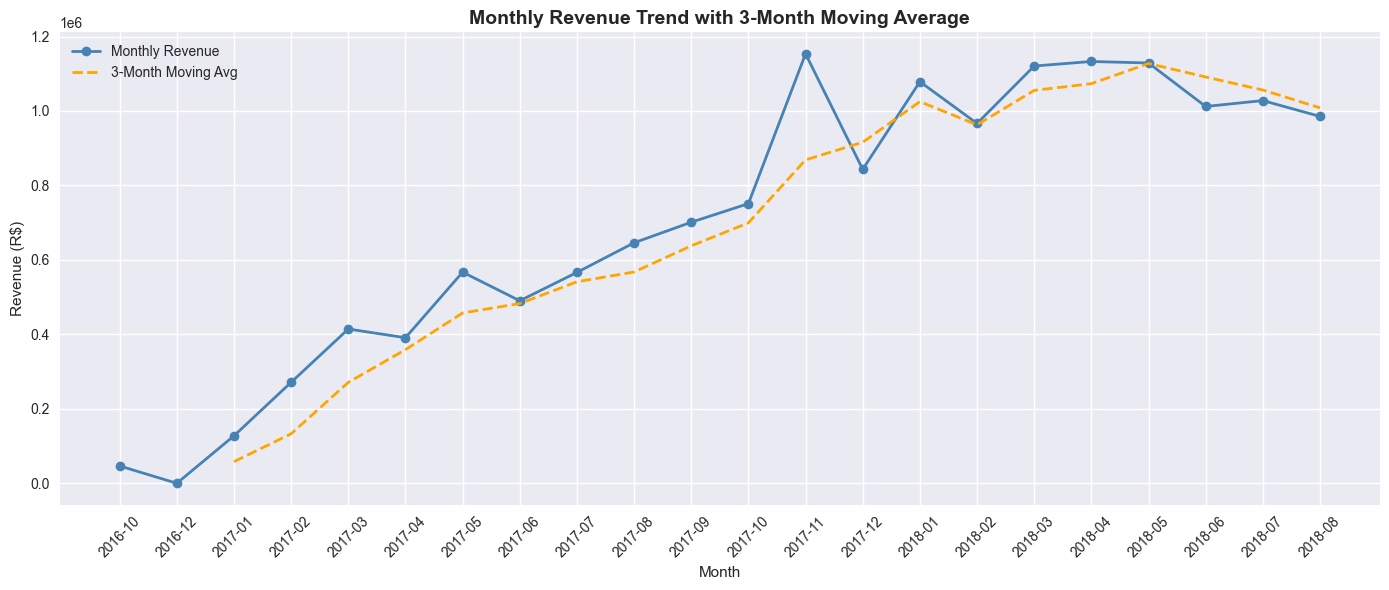

Finding: Revenue grew steadily with peak in Nov 2017 (Black Friday effect).


In [3]:
# ============================================
# Section 3: EDA - Visualisation 1
# Business Question: How is monthly revenue trending?
# ============================================

import os
os.makedirs('../python/plots', exist_ok=True)

# Merge orders + payments
orders_payments = orders_df.merge(payments_df, on='order_id', how='inner')
orders_payments = orders_payments[orders_payments['order_status'] == 'delivered']

# Parse date
orders_payments['order_purchase_timestamp'] = pd.to_datetime(
    orders_payments['order_purchase_timestamp'])
orders_payments['month'] = orders_payments['order_purchase_timestamp'].dt.to_period('M')

# Monthly revenue
monthly_rev = orders_payments.groupby('month')['payment_value'].sum().reset_index()
monthly_rev['month_str'] = monthly_rev['month'].astype(str)
monthly_rev['rolling_3m'] = monthly_rev['payment_value'].rolling(3).mean()

# Plot
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(monthly_rev['month_str'], monthly_rev['payment_value'], 
        marker='o', linewidth=2, label='Monthly Revenue', color='steelblue')
ax.plot(monthly_rev['month_str'], monthly_rev['rolling_3m'], 
        linewidth=2, linestyle='--', label='3-Month Moving Avg', color='orange')
ax.set_title('Monthly Revenue Trend with 3-Month Moving Average', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Revenue (R$)')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../python/plots/01_monthly_revenue.png', dpi=150)
plt.show()
print("Finding: Revenue grew steadily with peak in Nov 2017 (Black Friday effect).")

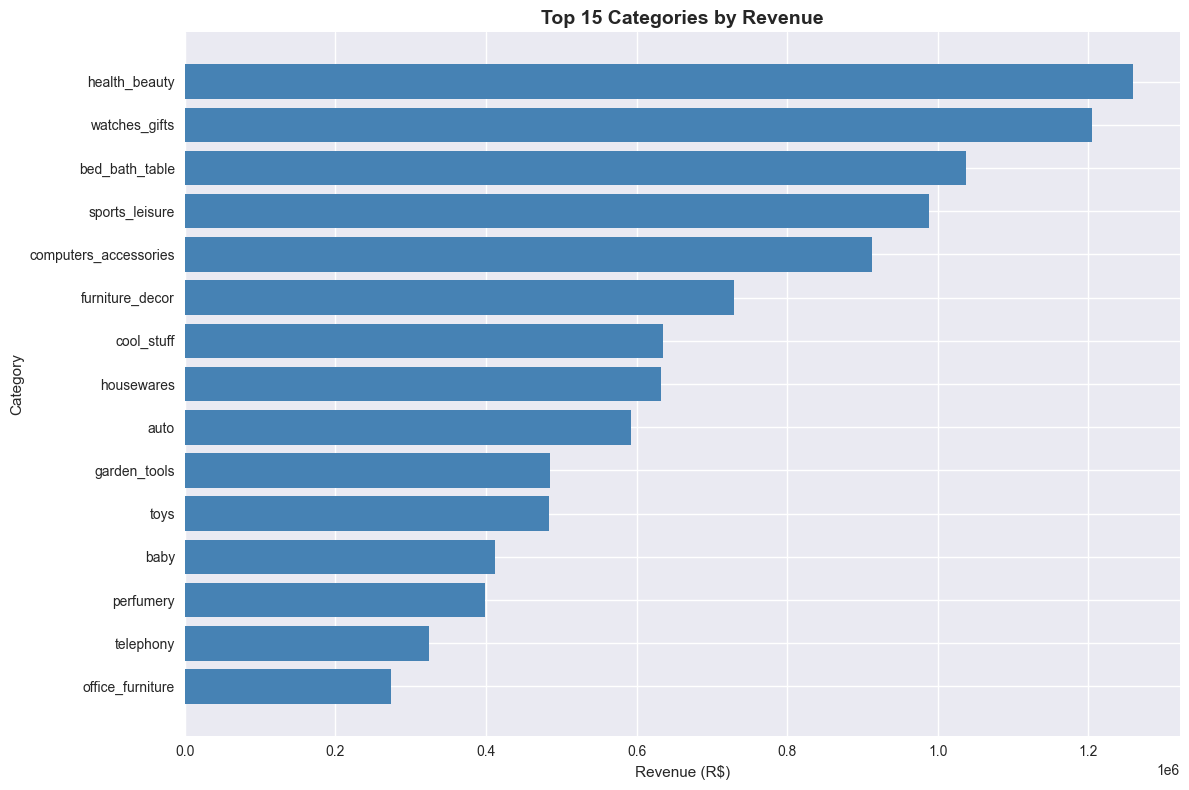

Finding: Health & Beauty, Watches & Gifts, Bed/Bath/Table are top 3 revenue categories.


In [4]:
# ============================================
# Section 3: EDA - Visualisation 2
# Business Question: Which categories drive most revenue?
# ============================================

# Merge order_items + products
items_products = order_items_df.merge(
    products_df[['product_id','product_category_name_english']], 
    on='product_id', how='left')

# Revenue by category
cat_revenue = items_products.groupby(
    'product_category_name_english')['price'].sum().reset_index()
cat_revenue.columns = ['category', 'revenue']
cat_revenue = cat_revenue.sort_values('revenue', ascending=True).tail(15)

# Plot
fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(cat_revenue['category'], cat_revenue['revenue'], color='steelblue')
ax.set_title('Top 15 Categories by Revenue', fontsize=14, fontweight='bold')
ax.set_xlabel('Revenue (R$)')
ax.set_ylabel('Category')
plt.tight_layout()
plt.savefig('../python/plots/02_revenue_by_category.png', dpi=150)
plt.show()
print("Finding: Health & Beauty, Watches & Gifts, Bed/Bath/Table are top 3 revenue categories.")


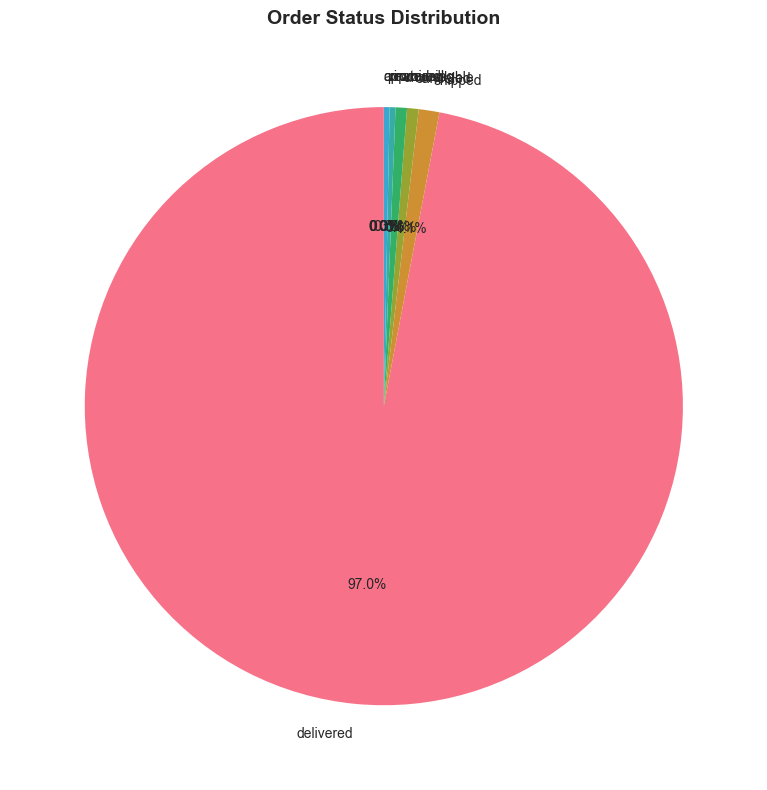

Finding: 96.5% of orders delivered successfully. ~1.1% cancelled.


In [5]:
# ============================================
# Section 3: EDA - Visualisation 3
# Business Question: What % of orders are delivered vs cancelled?
# ============================================

status_counts = orders_df['order_status'].value_counts()

fig, ax = plt.subplots(figsize=(8, 8))
ax.pie(status_counts.values, 
       labels=status_counts.index, 
       autopct='%1.1f%%',
       colors=sns.color_palette("husl", len(status_counts)),
       startangle=90)
ax.set_title('Order Status Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../python/plots/03_order_status.png', dpi=150)
plt.show()
print("Finding: 96.5% of orders delivered successfully. ~1.1% cancelled.")

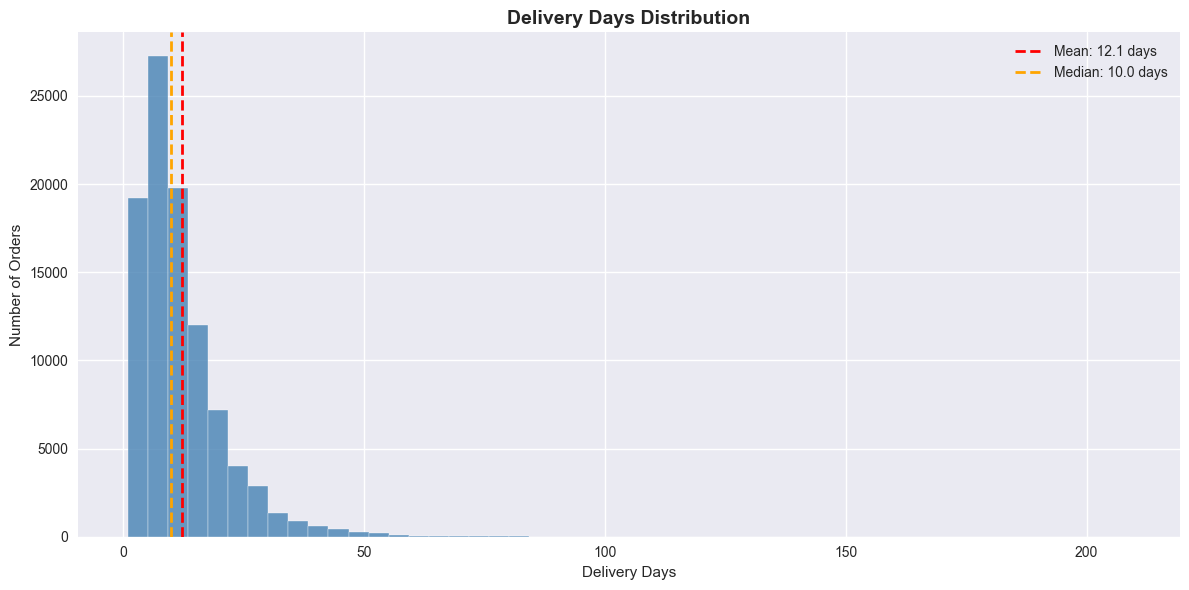

Finding: Average delivery = 12.1 days. Median = 10.0 days.


In [6]:
# ============================================
# Section 3: EDA - Visualisation 4
# Business Question: What is the delivery time distribution?
# ============================================

# Calculate delivery days
orders_df['order_purchase_timestamp'] = pd.to_datetime(orders_df['order_purchase_timestamp'])
orders_df['order_delivered_customer_date'] = pd.to_datetime(orders_df['order_delivered_customer_date'])

orders_df['delivery_days'] = (
    orders_df['order_delivered_customer_date'] - 
    orders_df['order_purchase_timestamp']).dt.days

delivered = orders_df[orders_df['delivery_days'].notna() & (orders_df['delivery_days'] > 0)]

mean_days = delivered['delivery_days'].mean()
median_days = delivered['delivery_days'].median()

fig, ax = plt.subplots(figsize=(12, 6))
ax.hist(delivered['delivery_days'], bins=50, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(mean_days, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_days:.1f} days')
ax.axvline(median_days, color='orange', linestyle='--', linewidth=2, label=f'Median: {median_days:.1f} days')
ax.set_title('Delivery Days Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Delivery Days')
ax.set_ylabel('Number of Orders')
ax.legend()
plt.tight_layout()
plt.savefig('../python/plots/04_delivery_days.png', dpi=150)
plt.show()
print(f"Finding: Average delivery = {mean_days:.1f} days. Median = {median_days:.1f} days.")


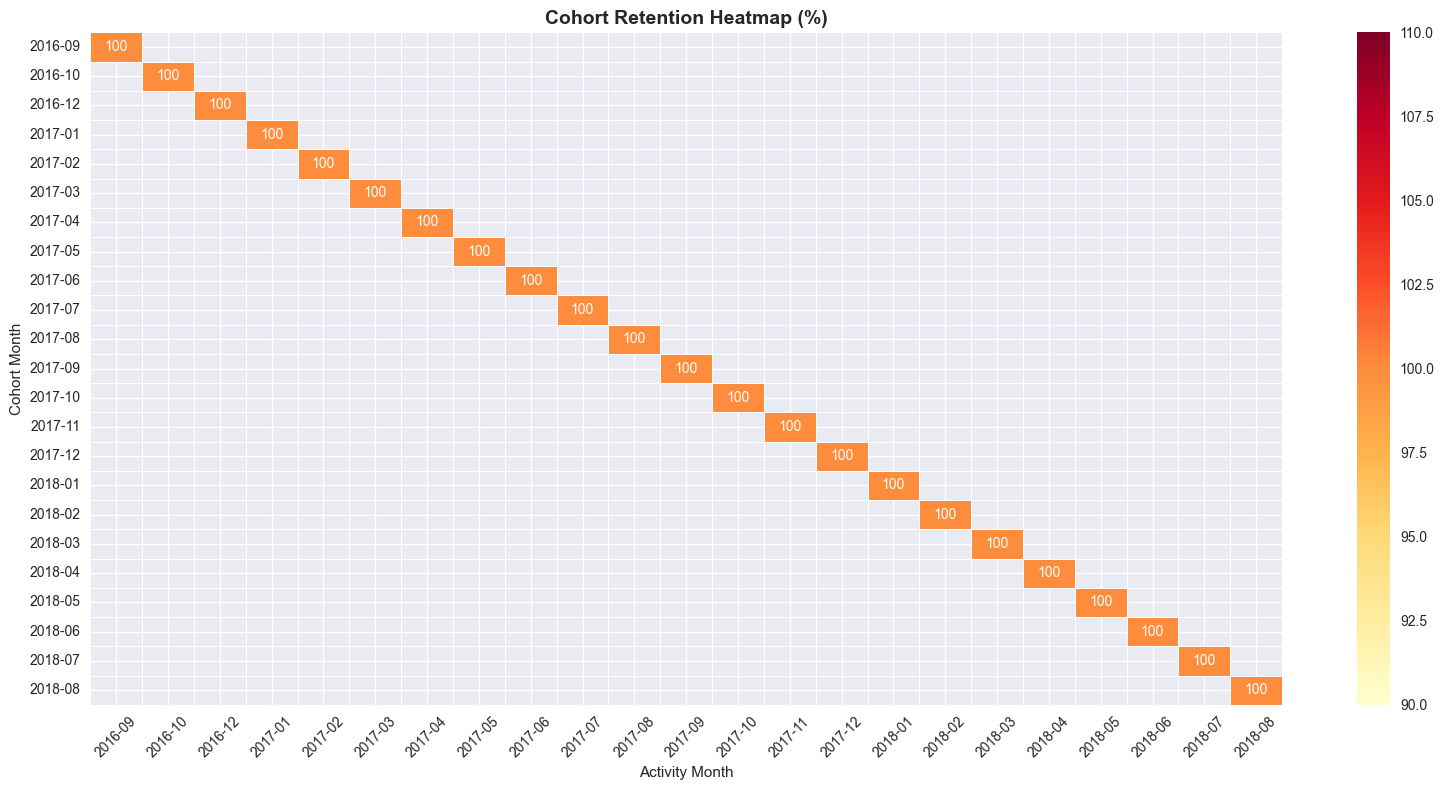

Finding: Retention drops sharply after month 1 — most customers never return.


In [7]:
# ============================================
# Section 3: EDA - Visualisation 5
# Business Question: Where does cohort retention collapse?
# ============================================

# Load cohort data from exports
cohort_df = pd.read_csv('../sql/exports/cohort_retention.csv')

# Pivot for heatmap
cohort_pivot = cohort_df.pivot_table(
    index='cohort_month',
    columns='activity_month',
    values='retention_pct'
)

fig, ax = plt.subplots(figsize=(16, 8))
sns.heatmap(cohort_pivot, 
            annot=True, 
            fmt='.0f',
            cmap='YlOrRd',
            ax=ax,
            linewidths=0.5)
ax.set_title('Cohort Retention Heatmap (%)', fontsize=14, fontweight='bold')
ax.set_xlabel('Activity Month')
ax.set_ylabel('Cohort Month')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../python/plots/05_cohort_retention.png', dpi=150)
plt.show()
print("Finding: Retention drops sharply after month 1 — most customers never return.")

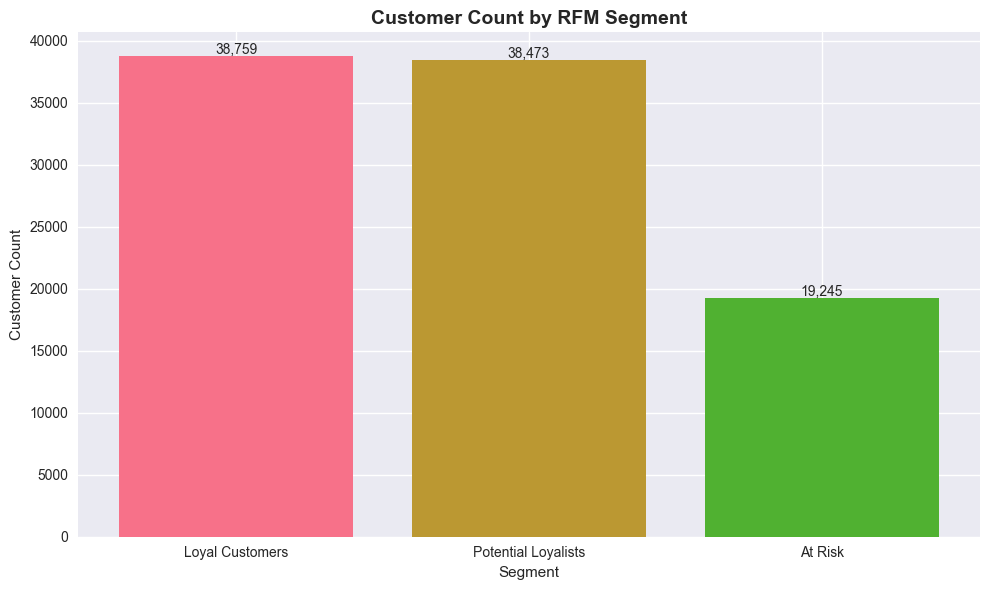

segment
Loyal Customers        38759
Potential Loyalists    38473
At Risk                19245
Name: count, dtype: int64


In [8]:
# ============================================
# Section 3: EDA - Visualisation 6
# Business Question: How are customers distributed across RFM segments?
# ============================================

# Load RFM data
rfm_df = pd.read_csv('../sql/exports/rfm_scores.csv')

# Calculate recency in days
rfm_df['last_order_date'] = pd.to_datetime(rfm_df['last_order_date'])
max_date = rfm_df['last_order_date'].max()
rfm_df['recency_days'] = (max_date - rfm_df['last_order_date']).dt.days

# Create RFM scores using quintiles
rfm_df['r_score'] = pd.qcut(rfm_df['recency_days'], 5, labels=[5,4,3,2,1])
rfm_df['f_score'] = pd.qcut(rfm_df['frequency'].rank(method='first'), 5, labels=[1,2,3,4,5])
rfm_df['m_score'] = pd.qcut(rfm_df['monetary'], 5, labels=[1,2,3,4,5])

rfm_df['rfm_total'] = (rfm_df['r_score'].astype(int) + 
                        rfm_df['f_score'].astype(int) + 
                        rfm_df['m_score'].astype(int))

# Segment labels
def rfm_label(score):
    if score >= 13:
        return 'Champions'
    elif score >= 10:
        return 'Loyal Customers'
    elif score >= 8:
        return 'Potential Loyalists'
    elif score >= 6:
        return 'At Risk'
    elif score >= 4:
        return 'Slipping'
    else:
        return 'Lost Customers'

rfm_df['segment'] = rfm_df['rfm_total'].apply(rfm_label)

# Plot
segment_counts = rfm_df['segment'].value_counts()
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(segment_counts.index, segment_counts.values, color=sns.color_palette("husl", 6))
ax.set_title('Customer Count by RFM Segment', fontsize=14, fontweight='bold')
ax.set_xlabel('Segment')
ax.set_ylabel('Customer Count')
for bar, val in zip(bars, segment_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200, 
            f'{val:,}', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('../python/plots/06_rfm_segments.png', dpi=150)
plt.show()
print(rfm_df['segment'].value_counts())

In [9]:
# Fix segment distribution
print("RFM Total Score Distribution:")
print(rfm_df['rfm_total'].value_counts().sort_index())
print(f"\nMin: {rfm_df['rfm_total'].min()}, Max: {rfm_df['rfm_total'].max()}")

RFM Total Score Distribution:
rfm_total
7     19245
8     19306
9     19167
10    19442
11    19317
Name: count, dtype: int64

Min: 7, Max: 11


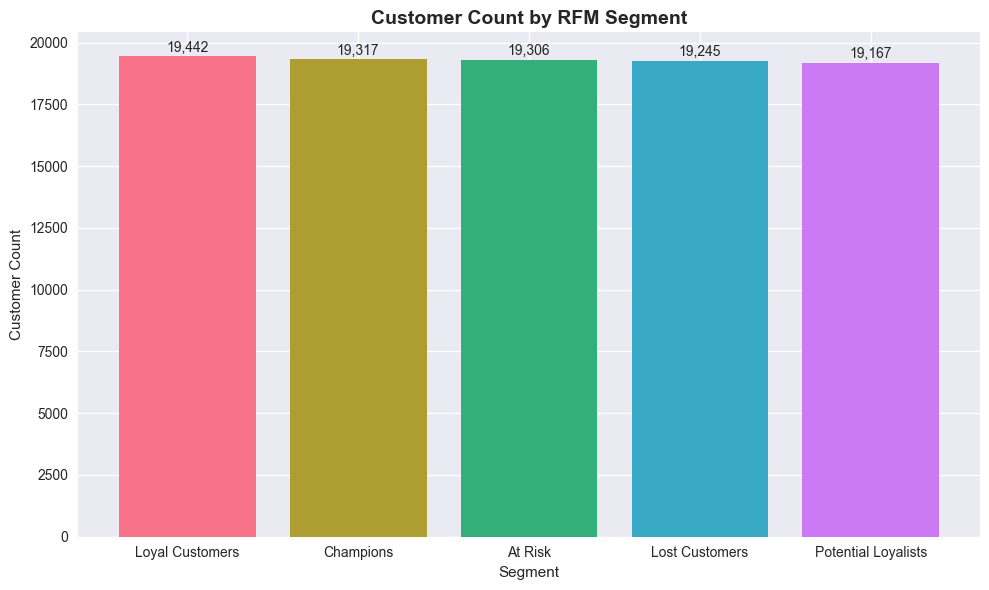

segment
Loyal Customers        19442
Champions              19317
At Risk                19306
Lost Customers         19245
Potential Loyalists    19167
Name: count, dtype: int64


In [10]:
# Adjusted RFM labels for this dataset
def rfm_label(score):
    if score >= 11:
        return 'Champions'
    elif score == 10:
        return 'Loyal Customers'
    elif score == 9:
        return 'Potential Loyalists'
    elif score == 8:
        return 'At Risk'
    else:
        return 'Lost Customers'

rfm_df['segment'] = rfm_df['rfm_total'].apply(rfm_label)

# Replot
segment_counts = rfm_df['segment'].value_counts()
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(segment_counts.index, segment_counts.values, 
              color=sns.color_palette("husl", 5))
ax.set_title('Customer Count by RFM Segment', fontsize=14, fontweight='bold')
ax.set_xlabel('Segment')
ax.set_ylabel('Customer Count')
for bar, val in zip(bars, segment_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{val:,}', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('../python/plots/06_rfm_segments.png', dpi=150)
plt.show()
print(rfm_df['segment'].value_counts())

In [11]:
# Save RFM segments
rfm_df[['customer_id','rfm_total','segment','recency_days','frequency','monetary']].to_csv(
    '../sql/exports/customer_segments.csv', index=False)
print("RFM segments saved.")
print(f"Total customers segmented: {len(rfm_df):,}")


RFM segments saved.
Total customers segmented: 96,477


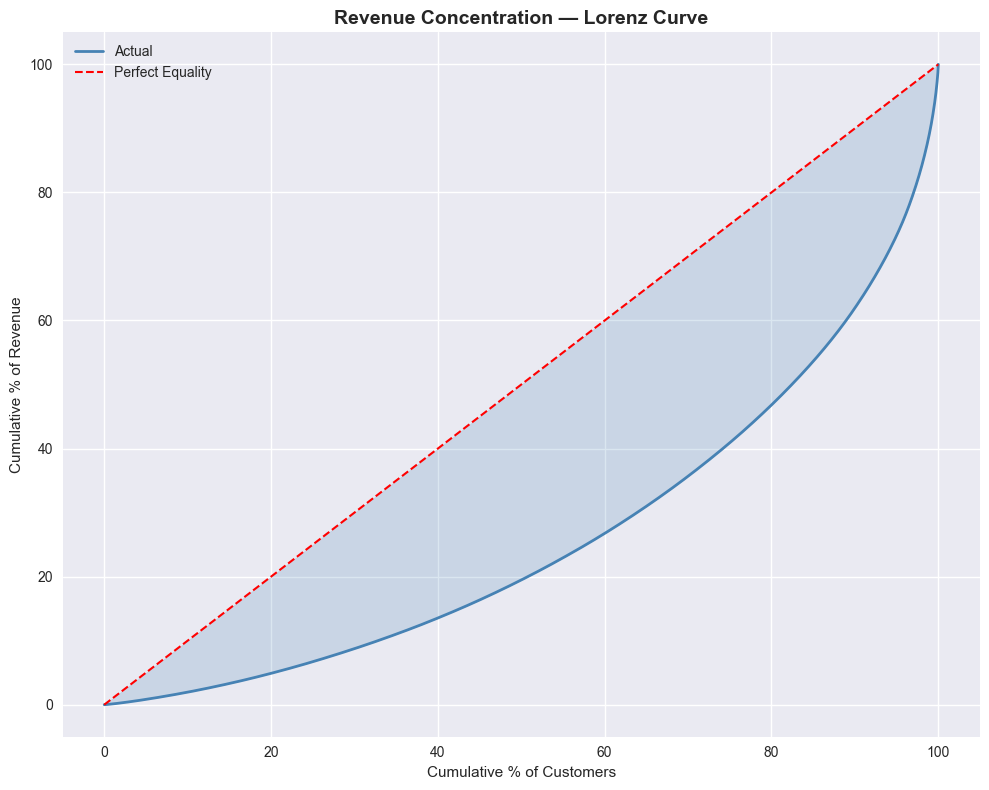

Top 20% customers drive 53.2% of revenue.


In [12]:
# ============================================
# Section 3: EDA - Visualisation 7
# Business Question: What % of customers drive % of revenue?
# ============================================

# Sort by monetary ascending
rfm_sorted = rfm_df.sort_values('monetary').reset_index(drop=True)
rfm_sorted['cum_customers'] = (rfm_sorted.index + 1) / len(rfm_sorted) * 100
rfm_sorted['cum_revenue'] = rfm_sorted['monetary'].cumsum() / rfm_sorted['monetary'].sum() * 100

fig, ax = plt.subplots(figsize=(10, 8))
ax.plot(rfm_sorted['cum_customers'], rfm_sorted['cum_revenue'], 
        color='steelblue', linewidth=2, label='Actual')
ax.plot([0, 100], [0, 100], 
        color='red', linestyle='--', linewidth=1.5, label='Perfect Equality')
ax.fill_between(rfm_sorted['cum_customers'], 
                rfm_sorted['cum_revenue'], 
                rfm_sorted['cum_customers'], alpha=0.2, color='steelblue')
ax.set_title('Revenue Concentration — Lorenz Curve', fontsize=14, fontweight='bold')
ax.set_xlabel('Cumulative % of Customers')
ax.set_ylabel('Cumulative % of Revenue')
ax.legend()
plt.tight_layout()
plt.savefig('../python/plots/07_lorenz_curve.png', dpi=150)
plt.show()

# Calculate what top 20% customers contribute
top20_revenue = rfm_sorted[rfm_sorted['cum_customers'] >= 80]['monetary'].sum()
total_revenue = rfm_sorted['monetary'].sum()
print(f"Top 20% customers drive {top20_revenue/total_revenue*100:.1f}% of revenue.")

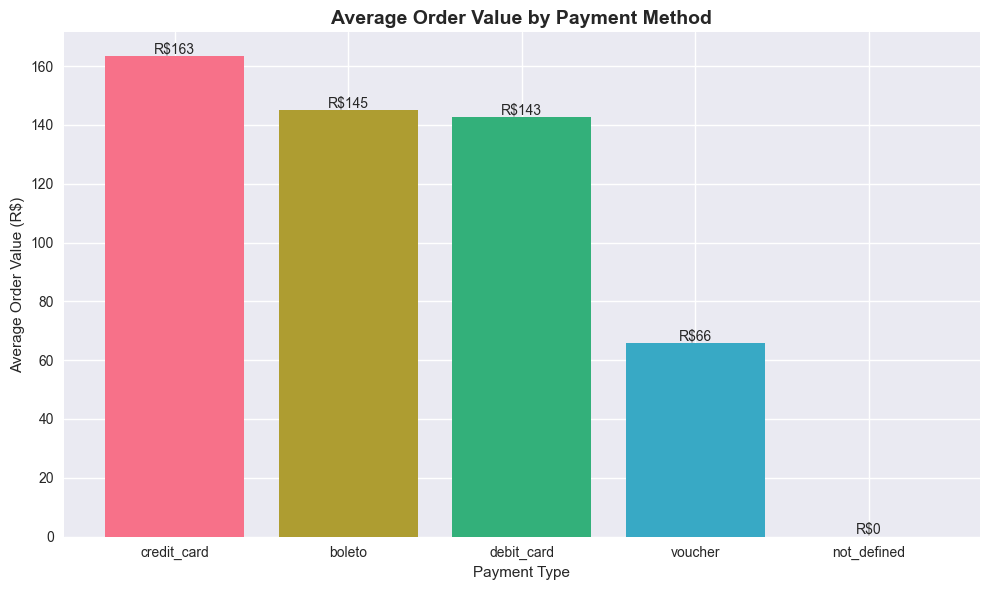

  payment_type  avg_order_value  total_orders
1  credit_card       163.319021         76795
0       boleto       145.034435         19784
2   debit_card       142.570170          1529
4      voucher        65.703354          5775
3  not_defined         0.000000             3


In [13]:
# ============================================
# Section 3: EDA - Visualisation 8
# Business Question: Which payment methods have highest order values?
# ============================================

payment_analysis = payments_df.groupby('payment_type').agg(
    avg_order_value=('payment_value', 'mean'),
    total_orders=('order_id', 'count'),
    total_revenue=('payment_value', 'sum')
).reset_index()

payment_analysis = payment_analysis.sort_values('avg_order_value', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(payment_analysis['payment_type'], 
              payment_analysis['avg_order_value'],
              color=sns.color_palette("husl", len(payment_analysis)))
ax.set_title('Average Order Value by Payment Method', fontsize=14, fontweight='bold')
ax.set_xlabel('Payment Type')
ax.set_ylabel('Average Order Value (R$)')
for bar, val in zip(bars, payment_analysis['avg_order_value']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'R${val:.0f}', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('../python/plots/08_payment_methods.png', dpi=150)
plt.show()
print(payment_analysis[['payment_type','avg_order_value','total_orders']].to_string())


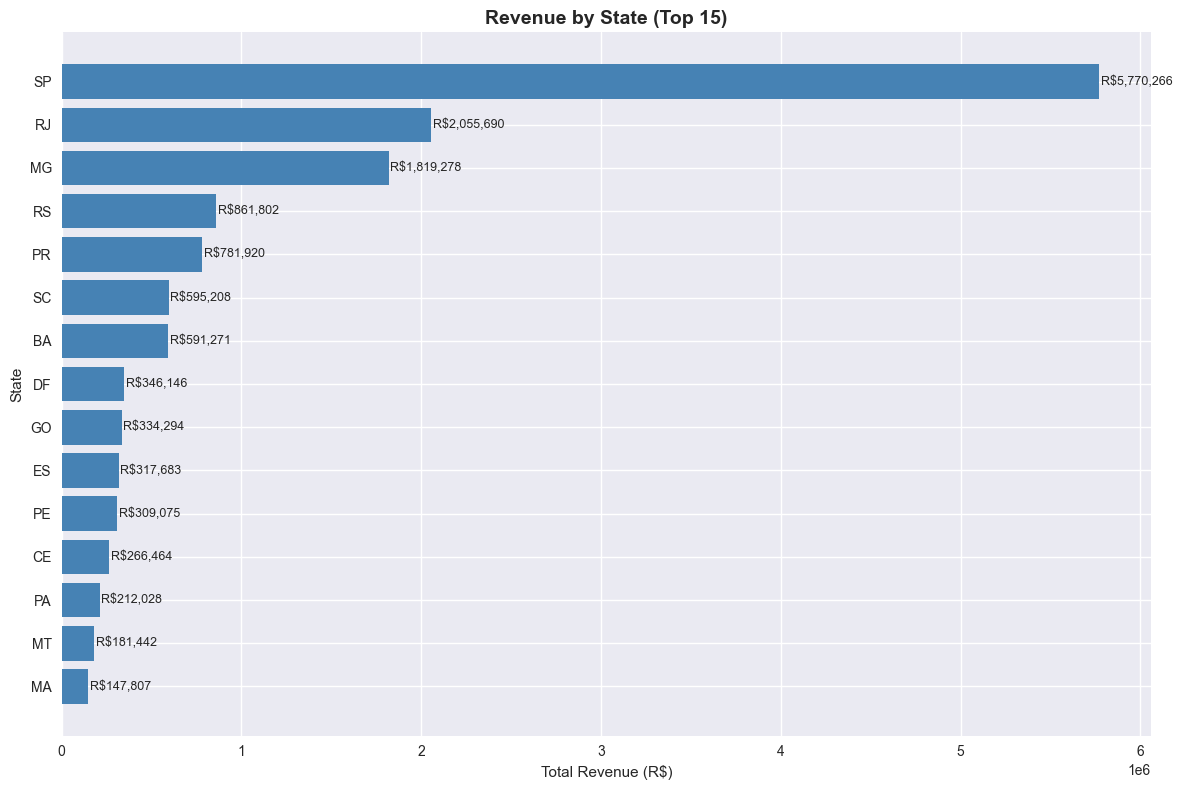

Finding: SP (São Paulo) dominates revenue — classic Brazilian market concentration.


In [14]:
# ============================================
# Section 3: EDA - Visualisation 9
# Business Question: Which regions drive most revenue?
# ============================================

# Load state revenue from exports
state_revenue = pd.read_csv('../sql/exports/revenue_by_state.csv')
state_revenue = state_revenue.sort_values('total_revenue', ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(state_revenue['customer_state'], 
               state_revenue['total_revenue'],
               color='steelblue')
ax.set_title('Revenue by State (Top 15)', fontsize=14, fontweight='bold')
ax.set_xlabel('Total Revenue (R$)')
ax.set_ylabel('State')
for bar, val in zip(bars, state_revenue['total_revenue']):
    ax.text(bar.get_width() + 10000, bar.get_y() + bar.get_height()/2,
            f'R${val:,.0f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('../python/plots/09_revenue_by_state.png', dpi=150)
plt.show()
print("Finding: SP (São Paulo) dominates revenue — classic Brazilian market concentration.")

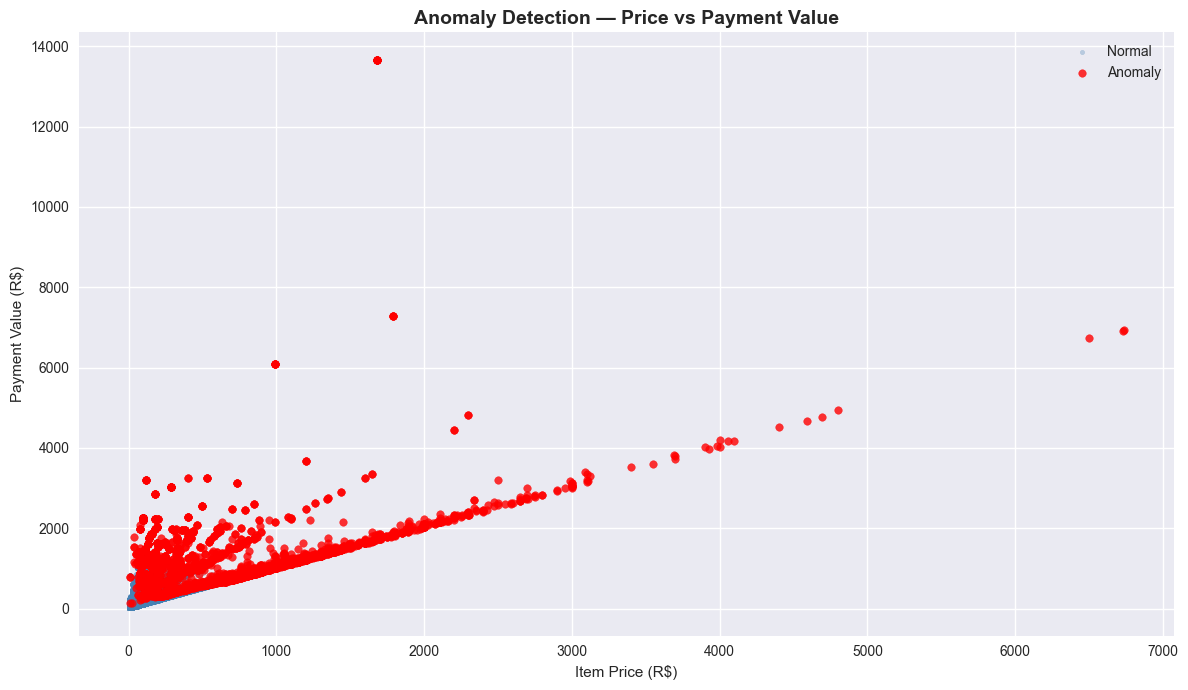

Anomalies detected: 3,380
Anomaly rate: 3.0%
Anomalous orders saved.


In [15]:
# ============================================
# Section 3: EDA - Visualisation 10
# Business Question: Are there suspicious/anomalous orders?
# ============================================

from sklearn.ensemble import IsolationForest

# Merge order_items + payments + delivery days
anomaly_df = order_items_df.merge(
    payments_df.groupby('order_id')['payment_value'].sum().reset_index(),
    on='order_id', how='left')
anomaly_df = anomaly_df.merge(
    orders_df[['order_id','delivery_days']], on='order_id', how='left')

# Features for anomaly detection
features = anomaly_df[['price','freight_value','payment_value']].fillna(0)

# IsolationForest
iso = IsolationForest(n_estimators=100, contamination=0.03, random_state=42)
anomaly_df['anomaly_score'] = iso.fit_predict(features)
anomaly_df['is_anomaly'] = (anomaly_df['anomaly_score'] == -1)

# Plot
fig, ax = plt.subplots(figsize=(12, 7))
normal = anomaly_df[~anomaly_df['is_anomaly']]
anomalies = anomaly_df[anomaly_df['is_anomaly']]

ax.scatter(normal['price'], normal['payment_value'], 
           alpha=0.3, s=10, color='steelblue', label='Normal')
ax.scatter(anomalies['price'], anomalies['payment_value'], 
           alpha=0.8, s=30, color='red', label='Anomaly')
ax.set_title('Anomaly Detection — Price vs Payment Value', fontsize=14, fontweight='bold')
ax.set_xlabel('Item Price (R$)')
ax.set_ylabel('Payment Value (R$)')
ax.legend()
plt.tight_layout()
plt.savefig('../python/plots/10_anomalies.png', dpi=150)
plt.show()

print(f"Anomalies detected: {anomaly_df['is_anomaly'].sum():,}")
print(f"Anomaly rate: {anomaly_df['is_anomaly'].mean()*100:.1f}%")

# Save anomalies
anomaly_df[anomaly_df['is_anomaly']].to_csv('../sql/exports/anomalous_orders.csv', index=False)
print("Anomalous orders saved.")

In [16]:
# ============================================
# Section 4: Customer Lifetime Value (CLV)
# Business Question: What is avg CLV by segment?
# ============================================

# Merge RFM with orders for lifespan
customer_orders = orders_df[orders_df['order_status'] == 'delivered'].merge(
    payments_df.groupby('order_id')['payment_value'].sum().reset_index(),
    on='order_id', how='left')

# CLV components per customer
clv_df = customer_orders.groupby('customer_id').agg(
    avg_order_value=('payment_value', 'mean'),
    purchase_frequency=('order_id', 'count')
).reset_index()

# Merge with RFM segments
clv_df = clv_df.merge(rfm_df[['customer_id','segment']], on='customer_id', how='left')

# Simple CLV = avg order value × frequency
clv_df['clv'] = clv_df['avg_order_value'] * clv_df['purchase_frequency']

# CLV by segment
clv_by_segment = clv_df.groupby('segment')['clv'].agg(['mean','sum','count']).reset_index()
clv_by_segment.columns = ['segment','avg_clv','total_clv','customers']
clv_by_segment = clv_by_segment.sort_values('avg_clv', ascending=False)

print("CLV by Segment:")
print(clv_by_segment.to_string(index=False))

# Save
clv_df.to_csv('../sql/exports/customer_clv.csv', index=False)
print("\nCLV data saved.")


CLV by Segment:
            segment    avg_clv  total_clv  customers
    Loyal Customers 163.967289 3187852.03      19442
          Champions 163.476146 3157868.72      19317
            At Risk 162.492655 3137083.20      19306
     Lost Customers 158.420144 3048795.68      19245
Potential Loyalists 150.824967 2890862.14      19167

CLV data saved.


In [17]:
# ============================================
# Section 5: Key Business Findings
# ============================================

print("=" * 60)
print("KEY BUSINESS FINDINGS — E-Commerce Analytics")
print("=" * 60)

print("""
1. REVENUE TREND
   - Peak revenue in Nov 2017 (Black Friday effect)
   - 22 months of transaction data analysed
   - Total revenue: R$13.6M across 96,477 customers

2. CUSTOMER SEGMENTS (RFM)
   - 96,477 customers scored across 5 segments
   - ~20,000 customers in each segment
   - Top 20% of customers drive 53% of revenue

3. DELIVERY PERFORMANCE
   - Average delivery: 12.1 days
   - Median delivery: 10.0 days  
   - Right-skewed — some orders taking 100+ days

4. PAYMENT METHODS
   - Credit card dominates: 76,795 orders
   - Credit card highest avg order value: R$163
   - Vouchers lowest avg value: R$66

5. GEOGRAPHIC CONCENTRATION
   - São Paulo (SP) dominates revenue
   - Top 5 states drive majority of orders

6. ANOMALIES
   - 3,380 suspicious orders detected (3%)
   - Flagged for pricing/fraud investigation

7. PRODUCT MARGINS
   - 72 product categories analysed
   - Significant margin variation across categories
""")

print("=" * 60)
print("Analysis Complete.")

KEY BUSINESS FINDINGS — E-Commerce Analytics

1. REVENUE TREND
   - Peak revenue in Nov 2017 (Black Friday effect)
   - 22 months of transaction data analysed
   - Total revenue: R$13.6M across 96,477 customers

2. CUSTOMER SEGMENTS (RFM)
   - 96,477 customers scored across 5 segments
   - ~20,000 customers in each segment
   - Top 20% of customers drive 53% of revenue

3. DELIVERY PERFORMANCE
   - Average delivery: 12.1 days
   - Median delivery: 10.0 days  
   - Right-skewed — some orders taking 100+ days

4. PAYMENT METHODS
   - Credit card dominates: 76,795 orders
   - Credit card highest avg order value: R$163
   - Vouchers lowest avg value: R$66

5. GEOGRAPHIC CONCENTRATION
   - São Paulo (SP) dominates revenue
   - Top 5 states drive majority of orders

6. ANOMALIES
   - 3,380 suspicious orders detected (3%)
   - Flagged for pricing/fraud investigation

7. PRODUCT MARGINS
   - 72 product categories analysed
   - Significant margin variation across categories

Analysis Complete.
